# Module 1.1 — Probability Theory & Statistics  
## The Mathematical Language of Uncertainty

Markets are not puzzles to be solved. They are uncertain systems to be navigated. Markets do not reward intelligence.
They reward disciplined thinking under uncertainty.

Quantitative finance does not begin with prediction. It begins with humility and mathematics.

Most beginners approach trading as a prediction problem:

- Where will price go?

- Is this signal real?

- Is this pattern bullish?

Professionals approach it differently:

- What is the distribution of outcomes?

- What is the expected value?

- What is the variance?

- What are the tail risks?

A probability model is not a claim about truth. It is a structured admission of ignorance.

Probability theory is the grammar of uncertainty. Statistics is the method of learning from it.

This notebook builds the probabilistic foundation that every robust trader, quant researcher, and risk manager must internalize.

We will study:

1. Probability spaces, random variables, and distributions  
2. Expected value, variance, moments, cumulants  
3. Joint distributions, covariance, correlation  
4. Law of Large Numbers & Central Limit Theorem  
5. Hypothesis testing in trading  

And we will simulate everything.

In [31]:
# Initial Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

plt.style.use("seaborn-v0_8")

## 1. Probability Spaces, Random Variables, and Distributions

### The Mathematical Framework

A probability space is written as:

$
(\Omega, \mathcal{F}, \mathbb{P})
$

This compact notation is one of the most powerful conceptual tools in finance.

- $\Omega $ is the set of all possible outcomes — all future return paths, all price evolutions, all market states.
- $ \mathcal{F} $ is the collection of events we care to measure — “drawdown exceeds 10%”, “volatility doubles”, “portfolio loss exceeds 5%”.
- $ \mathbb{P} $ is a probability measure — a consistent rule assigning belief to events.

In markets, $\Omega$ is not dice outcomes. It is the set of all possible future return paths. In other words, In finance, 
$\Omega$ is enormous. It contains every possible configuration of future price movements. We do not observe 
$\Omega$. We infer it. 

Every quantitative model — from Black–Scholes to GARCH to reinforcement learning — implicitly assumes a probability space.

The difference between amateurs and professionals is not access to information. It is awareness of the underlying probabilistic structure.

A random variable is a measurable mapping:

$
X : \Omega \rightarrow \mathbb{R}
$

It translates uncertainty into computation.

In finance, examples include:

- Daily return of an asset
- Portfolio PnL (Profit and Loss)
- Drawdowns
- Volatility
- Time to recovery

Once uncertainty becomes numeric, it becomes analyzable. Expected value, variance, correlation, tail probabilities — these are not abstract objects. They are decision-making tools.

A trader who thinks in single outcomes asks:
> “Will this trade work?”

A trader who thinks in random variables asks:

> “What is the distribution of outcomes?”

That shift changes everything.

### Philosophical Insight

A probability model is not truth. It is a disciplined structure imposed on uncertainty.

Professional traders differ from amateurs in one crucial way: They reason in distributions — not outcomes.

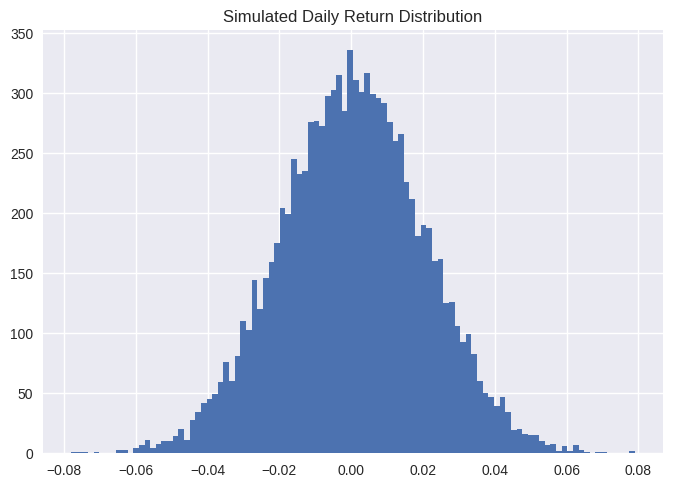

(np.float64(0.00045728033263147625), np.float64(0.020068244122599752))

In [2]:
# Simulate daily returns
mu = 0.0005
sigma = 0.02
n = 10000

returns = np.random.normal(mu, sigma, n)

plt.hist(returns, bins=100)
plt.title("Simulated Daily Return Distribution")
plt.show()

returns.mean(), returns.std()

## 2. Expected Value and Variance

### Expected Value

$
\mathbb{E}[X] = \int x d\mathbb{P}(x)
$

Expected value represents the long-run average outcome.

In trading:
- It represents your statistical edge, but the expected value alone is dangerous. 
- But it says nothing about path or survival.

A strategy with positive expected return can still go bankrupt if variance is too large.

### Variance

$
\mathrm{Var}(X) = \mathbb{E}[(X - \mu)^2]
$

Variance measures dispersion, or let's say an instability around the mean.
In finance, variance is volatility — the cost of uncertainty.

Volatility is not just noise. It determines survival.

Two strategies may have identical expected returns.
The one with lower variance compounds more reliably and survives deeper drawdowns.

Expected value defines opportunity. Variance defines fragility.

### Higher Moments: The Shape of Risk
Markets are not Gaussian. Empirical returns frequently exhibit
- Negative skewness (large downside moves),
- Excess kurtosis (fat tails).

Skewness measures asymmetry.
- Skewness → asymmetry

$
\mathrm{Skewness}(X) = \mathbb{E}[(\frac{X - \mu}{\sigma})^3]
$


Kurtosis measures tail heaviness:
- Kurtosis → fat tails

$
\mathrm{Kurtosis}(X) = \mathbb{E}[(\frac{X - \mu}{\sigma})^4]
$

Markets often exhibit:
- Negative skew
- Excess kurtosis

These are not academic details. They are why strategies blow up.
Many financial crises are kurtosis events. Strategies that appear stable under Gaussian assumptions collapse under fat-tailed reality. Ignoring higher moments  is not simplification, it is negligence. 

In [4]:
# Moments
mean = np.mean(returns)
variance = np.var(returns)
skew = stats.skew(returns)
kurtosis = stats.kurtosis(returns)

mean, variance, skew, kurtosis

(np.float64(0.00045728033263147625),
 np.float64(0.0004027344221642595),
 np.float64(0.0019636977663562375),
 np.float64(0.026479272360443673))

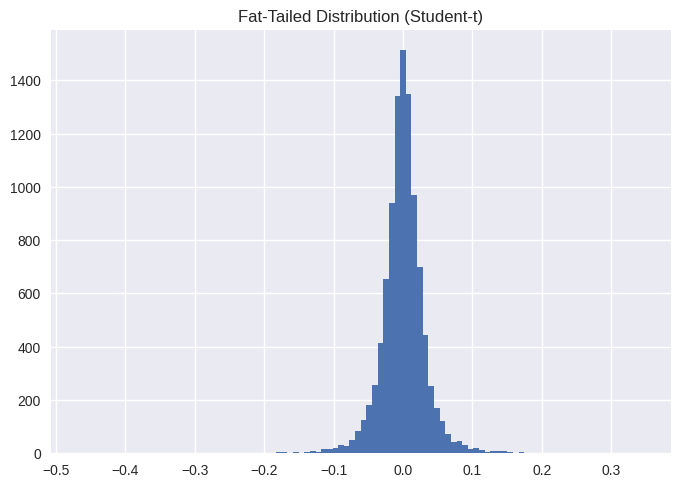

np.float64(17.022753983465265)

In [16]:
# Fat tail simulation
# Student-t distribution (fat tails)
t_returns = stats.t.rvs(df=3, size=n) * 0.02

plt.hist(t_returns, bins=100)
plt.title("Fat-Tailed Distribution (Student-t)")
plt.show()

stats.kurtosis(t_returns)

## 3. Joint Distributions and Dependence

Individual asset risk is rarely the real danger. Their dependence is. In portfolio theory, we care not only about returns, but also how assets move together.
Joint distributions describe how multiple random variables interact. 

### Covariance
Covariance is defined as
$
\mathrm{Cov}(X,Y) = \mathbb{E}[(X - \mu_X)(Y - \mu_Y)]
$

### Correlation
Correlation standardizes covariance
$
\rho = \frac{\mathrm{Cov}(X,Y)}{\sigma_X \sigma_Y}
$

Correlation measures linear dependence. Diversification depends on imperfect correlation. However, in crises, correlation increase, a phenomenon known as **correlation breakdown**. Understanding joint distributions is understanding systemic risk. Portfolio theory is not about picking assets, it is about managing dependence structure. 

### Philosophical Insight

Diversification works only if correlations are not 1.

But in crises, correlations tend to increase.

Understanding joint distributions is understanding systemic risk.

In [25]:
# Simulating Corelated Assets
rho = 0.01 #-1, 1, 0.7, -0.7, 0

cov_matrix = [[0.02**2, rho*0.02*0.03],
              [rho*0.02*0.03, 0.03**2]]

mean_vector = [0.0005, 0.0008]

data = np.random.multivariate_normal(mean_vector, cov_matrix, n)

asset1 = data[:,0]
asset2 = data[:,1]

np.corrcoef(asset1, asset2)

array([[1.        , 0.01457983],
       [0.01457983, 1.        ]])

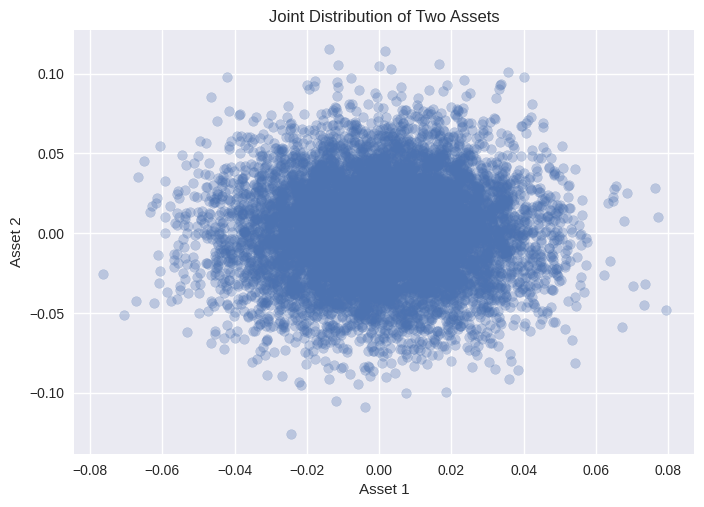

In [26]:
# Visualizing Correlation
plt.scatter(asset1, asset2, alpha=0.3)
plt.title("Joint Distribution of Two Assets")
plt.xlabel("Asset 1")
plt.ylabel("Asset 2")
plt.show()

## 4. Law of Large Numbers (LLN)
The Law of Large Numbers (LLN) states:

$
\bar{X}_n \rightarrow \mathbb{E}[X] \quad \text{as} \quad  n \rightarrow \infty
$

As sample size increases, the sample mean converges to the true mean.

### Trading Insight
This theorem is psychologically important. Your edge only appears with enough repetitions.
Short-term performance is noise. Without sufficient trades, you cannot distinguish skill from variance. The LLN teaches patience. 

---

## Central Limit Theorem (CLT)
The Central Limit Theorem (CLT) states:

$
\sqrt{n}(\bar{X}_n - \mu) \rightarrow N(0,\sigma^2) \quad \text{as} \quad n \rightarrow \infty
$

Regardless of underlying distribution (under mild conditions), the distribution of sample means tend toward normality. This result enables:
- Confidence intervals
- Hypothesis testing
- Sharpe ratio approximations

The CLT is why statistical inference is possible in finance. But it also reminds us:
> Inference is approximate, not absolute.


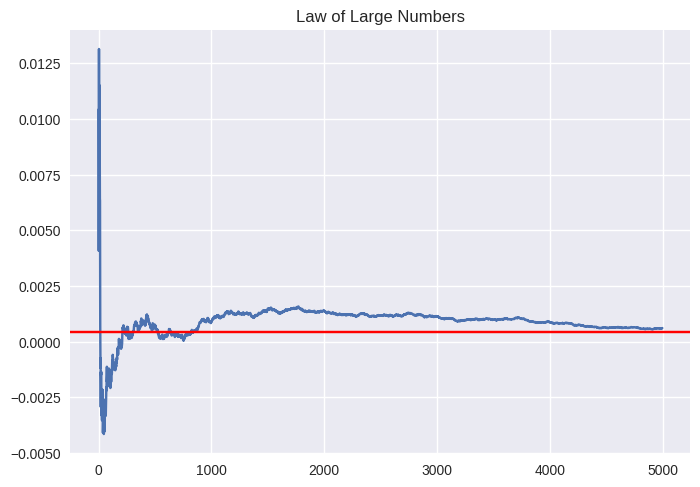

In [27]:
# LLN Simulation
means = []
for i in range(1, 5000):
    means.append(np.mean(returns[:i]))

plt.plot(means)
plt.axhline(mean, color='red')
plt.title("Law of Large Numbers")
plt.show()

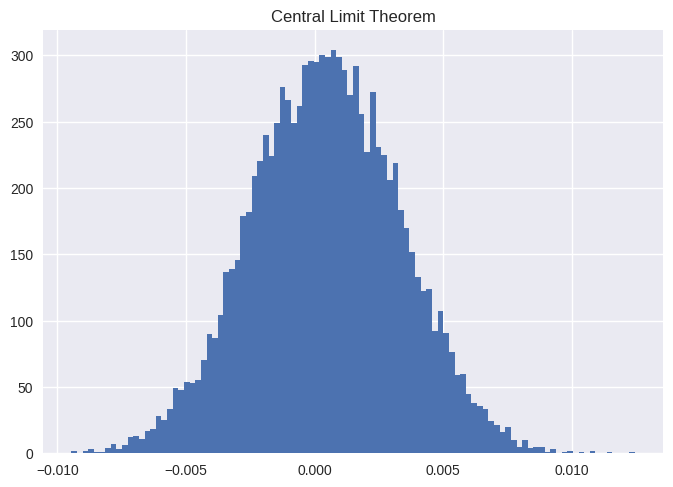

In [28]:
# CLT Simulation
sample_means = []

for _ in range(10000):
    sample = np.random.choice(returns, size=50)
    sample_means.append(np.mean(sample))

plt.hist(sample_means, bins=100)
plt.title("Central Limit Theorem")
plt.show()

## 5. Hypothesis Testing

In trading, we constantly ask:

"Is this strategy profitable,
or is this just randomness?"

### Null Hypothesis

$
H_0: \mu = 0
$

### Alternative

$
H_1: \mu \neq 0
$

We compute a test statistic:

$
t = \frac{\bar{X}}{s / \sqrt{n}}
$

Then compute a p-value.

### Philosophical Warning
If the p-value is small, we reject the null hypothesis.

However:

- Markets adapt.
- Data-snooping inflates significance.
- Overfitting produces false edges.

Statistical significance does not equal economic significance.

Professional quants understand that hypothesis testing is a filter — not a guarantee.
Small p-values do not guarantee profitability.

In [29]:
# t test
t_stat, p_value = stats.ttest_1samp(returns, 0)

t_stat, p_value

(np.float64(2.2785125856042256), np.float64(0.02271704937726958))

In [30]:
# Monte Carlo Significance Test
# Monte Carlo test of mean > 0
n_sim = 10000
sim_means = []

for _ in range(n_sim):
    sim = np.random.normal(0, sigma, n)
    sim_means.append(np.mean(sim))

sim_means = np.array(sim_means)

np.mean(sim_means >= mean)

np.float64(0.0102)

# Final Reflection (Professional Mindset)
Probability theory and statistics are not academic prerequisites. They are survival tools. 
Quant finance is not prediction.
It is structured reasoning under uncertainty.

A professional quant:

- Thinks in distributions, not outcomes, 
- Understands dependence structures,
- Respects variance and tail risk,
- Uses LLN to remain patience,
- Applies hypothesis testing cautiously.

Markets punish certainty.
They reward disciplined probabilistic reasoning.

Quantitative finance is not prediction.

It is the art of making decisions under uncertainty while minimizing self-deception.

Before you build strategies, optimize portfolios, or deploy models, you must internalize this:

> The market is not a deterministic machine.
>
> It is a probabilistic system and you operate inside its distribution.

In the next module, we move from probability to linear algebra — the geometry of risk — and see how covariance structures shape portfolio construction.